In [18]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

In [19]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
vhc_sector = get_preprocessing_data("vehicles", base_dir, cache = "vhc_sector.nc")

circular_economy_scenario_dirs = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir = base_dir / 'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = "vhc_sector_slow.nc")


In [20]:
# Define simulation parameters
time_start = 1970
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(2000, 2100, 1)

scenario_list = {
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}


In [21]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    print(f"\n=== Running Scenario: {scen_id} ===")
    
    # Select the appropriate sector data based on circular economy scenario
    if scenario_config['circular_scen'] == 'standard':
        sector_data = vhc_sector
        print("Using standard sector data")
    elif scenario_config['circular_scen'] == 'slow':
        sector_data = vhc_sector_slow
        print("Using slow circular economy sector data")
    
    # Create factory with appropriate sector data
    factory = ModelFactory(
        sector_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials)
    
    # Add the appropriate maintenance model based on maintenance scenario
    if scenario_config['maintenance_scen'] == 'constant':
        factory = factory.add(Maintenance)
        print("Using constant maintenance model")
    elif scenario_config['maintenance_scen'] == 'linear':
        # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
        factory = factory.add(MaintenanceLinear)
        print("Using linear maintenance model with explicit vehicle lifetimes")
    
    # Finish model creation
    model = factory.finish()
    
    # Run simulation
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
    
    # Store results
    all_output[scen_id] = {
        'model': model,
        'inflow_maintenance': model.inflow_maintenance.to_array(),
        'circular_scenario': scenario_config['circular_scen'],
        'maintenance_scenario': scenario_config['maintenance_scen'],
        'label': scenario_config['label']
    }
    
    print(f"✓ Completed: {scen_id}")

print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
print("Available scenarios:", list(all_output.keys()))



=== Running Scenario: standard_constant ===
Using standard sector data
Using constant maintenance model
✓ Completed: standard_constant

=== Running Scenario: standard_linear ===
Using standard sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes
✓ Completed: standard_linear

=== Running Scenario: slow_constant ===
Using slow circular economy sector data
Using constant maintenance model
✓ Completed: slow_constant

=== Running Scenario: slow_linear ===
Using slow circular economy sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes
✓ Completed: slow_linear

=== All 4 scenarios completed successfully ===
Available scenarios: ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']



Processing scenario: standard_constant
maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (131, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: standard_linear
maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (131, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: slow_constant
maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data sh

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (131, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (131, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']


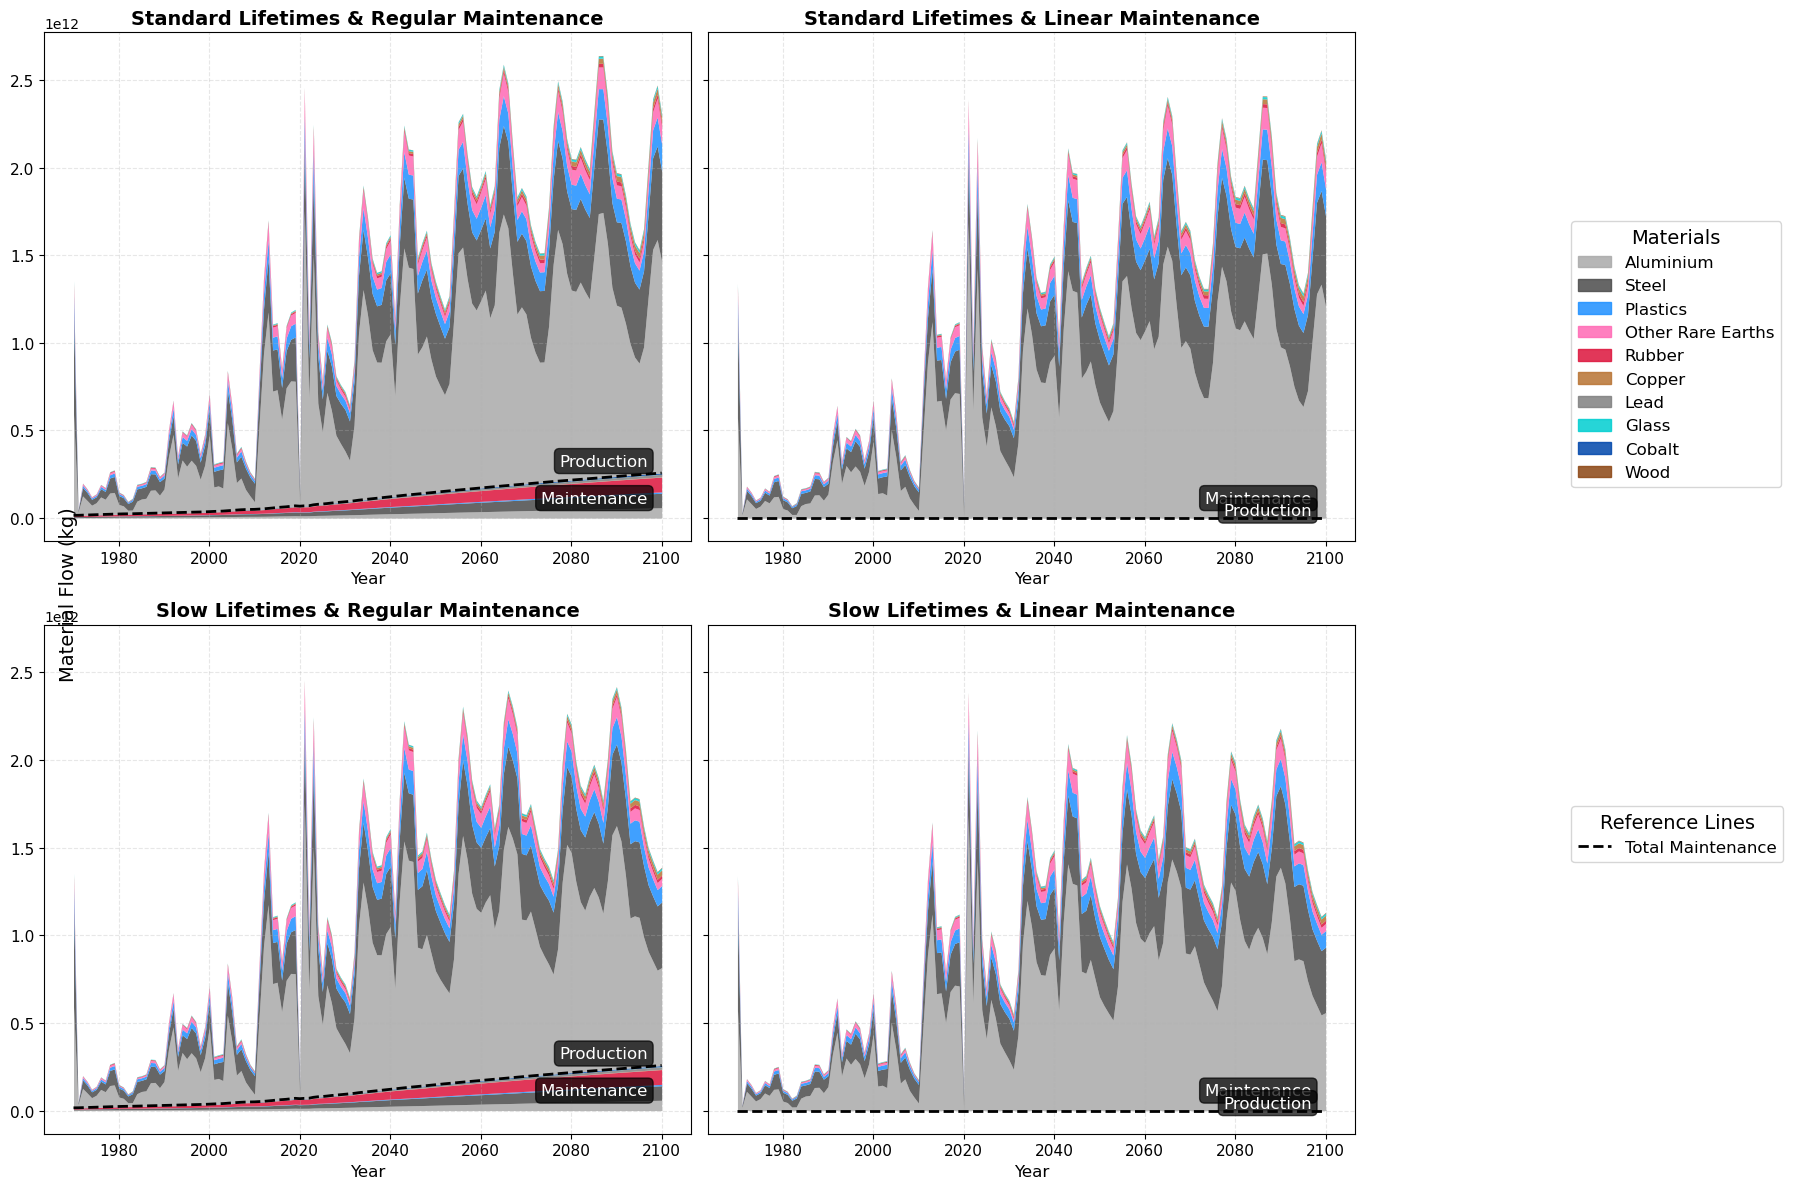

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with materials stacked and uniform coloring across plots.
"""

# Define material colors (customize as needed)
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

# Helper function to process data for each scenario
def process_scenario_data(scenario_data):
    # Get maintenance and production data, sum over Region and Type
    maint_data = scenario_data['inflow_maintenance'].sum(dim=['Region', 'Type'])
    prod_data = scenario_data["model"].inflow_materials.to_array().sum(dim=['Region', 'Type'])
        
    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas()
    prod_df = prod_data.to_pandas() 
    
    # Process both dataframes similarly
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        
        # Group rare earth elements
        rare_earths = ["Nd", "Mn", "Ni", "Ti", "Li"]
        existing_rare_earths = [re for re in rare_earths if re in df.columns]
        if existing_rare_earths:
            df["Other Rare Earths"] = df[existing_rare_earths].sum(axis=1)
            df.drop(columns=existing_rare_earths, inplace=True, errors="ignore")
        
        # Rename materials for better display
        rename_map = {
            "Pb": "Lead",
            "Co": "Cobalt", 
            "Cu": "Copper",
            "Al": "Aluminum"
        }
        df.rename(columns=rename_map, inplace=True)
        
        # Filter from 2000 onwards
        df = df[df.index >= 2010]
        
        # Keep only non-zero materials
        valid_materials = (df != 0).any(axis=0)
        df = df.loc[:, valid_materials]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_materials = set(maint_df.columns) | set(prod_df.columns)
        for mat in all_materials:
            if mat not in maint_df.columns:
                maint_df[mat] = 0
            if mat not in prod_df.columns:
                prod_df[mat] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_materials = maint_df + prod_df
        sorted_cols = total_materials.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data(scen_data)
    if not maint_df.empty:
        processed_data[scen_id] = {'maintenance': maint_df, 'production': prod_df}


# Get all unique materials across scenarios for consistent coloring
all_materials = set()
for scen_data in processed_data.values():
    all_materials.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_materials.update(scen_data['production'].columns)

# Update material colors to include any missing materials
for material in all_materials:
    if material not in material_colors:
        material_colors[material] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data[scen_id]['maintenance']
    prod_df = processed_data[scen_id]['production']
    
    # Plot maintenance (bottom layer)
    colors_list = [material_colors.get(mat, '#999999') for mat in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for mat in prod_df.columns:
            if mat in prod_df.columns and not prod_df[mat].isna().all():
                top = prod_bottom + prod_df[mat]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=material_colors.get(mat, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(0.04, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for materials
if processed_data:
    # Get materials from the first scenario for legend order
    first_scenario = list(processed_data.values())[0]
    legend_materials = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=material_colors[mat], alpha=0.85) 
                        for mat in legend_materials]
    
    # Add materials legend
    fig.legend(
        legend_handles, 
        legend_materials,
        title="Materials", 
        bbox_to_anchor=(0.98, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.98, 0.3), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()
